In [1]:
import pyemu
import os
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning) 
import pandas as pd
import matplotlib.pyplot as plt
import psutil
import shutil
import numpy as np
import sys
from swatmf import analyzer

D:\spark-brc_gits\swatmf_wf\dependencies\pyemu\pyemu\pst\pst_handler.py:15: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.


# 01. Set working directory

In [2]:
# path to project directory
wd = "D:\\Projects\\Watersheds\\Koksilah\\analysis\\koksilah_git\\koki_zon_rw_ies"
os.chdir(wd)

# 05. Analyze results
## 05.1 Check model performance

In [3]:
pst_file = "koki_zon_rw_ies.pst"

In [4]:
pst_file[:-4]

'koki_zon_rw_ies'

In [5]:
pst = pyemu.Pst(pst_file) # load control file

In [6]:
post_iter_num = 3

In [7]:
# load prior simulation
pr_oe = pyemu.ObservationEnsemble.from_csv(
    pst=pst,filename=f'{pst_file[:-4]}.0.obs.csv'
    )
# load posterior simulation
pt_oe = pyemu.ObservationEnsemble.from_csv(
    pst=pst,filename=f'{pst_file[:-4]}.{post_iter_num}.obs.csv'
    )


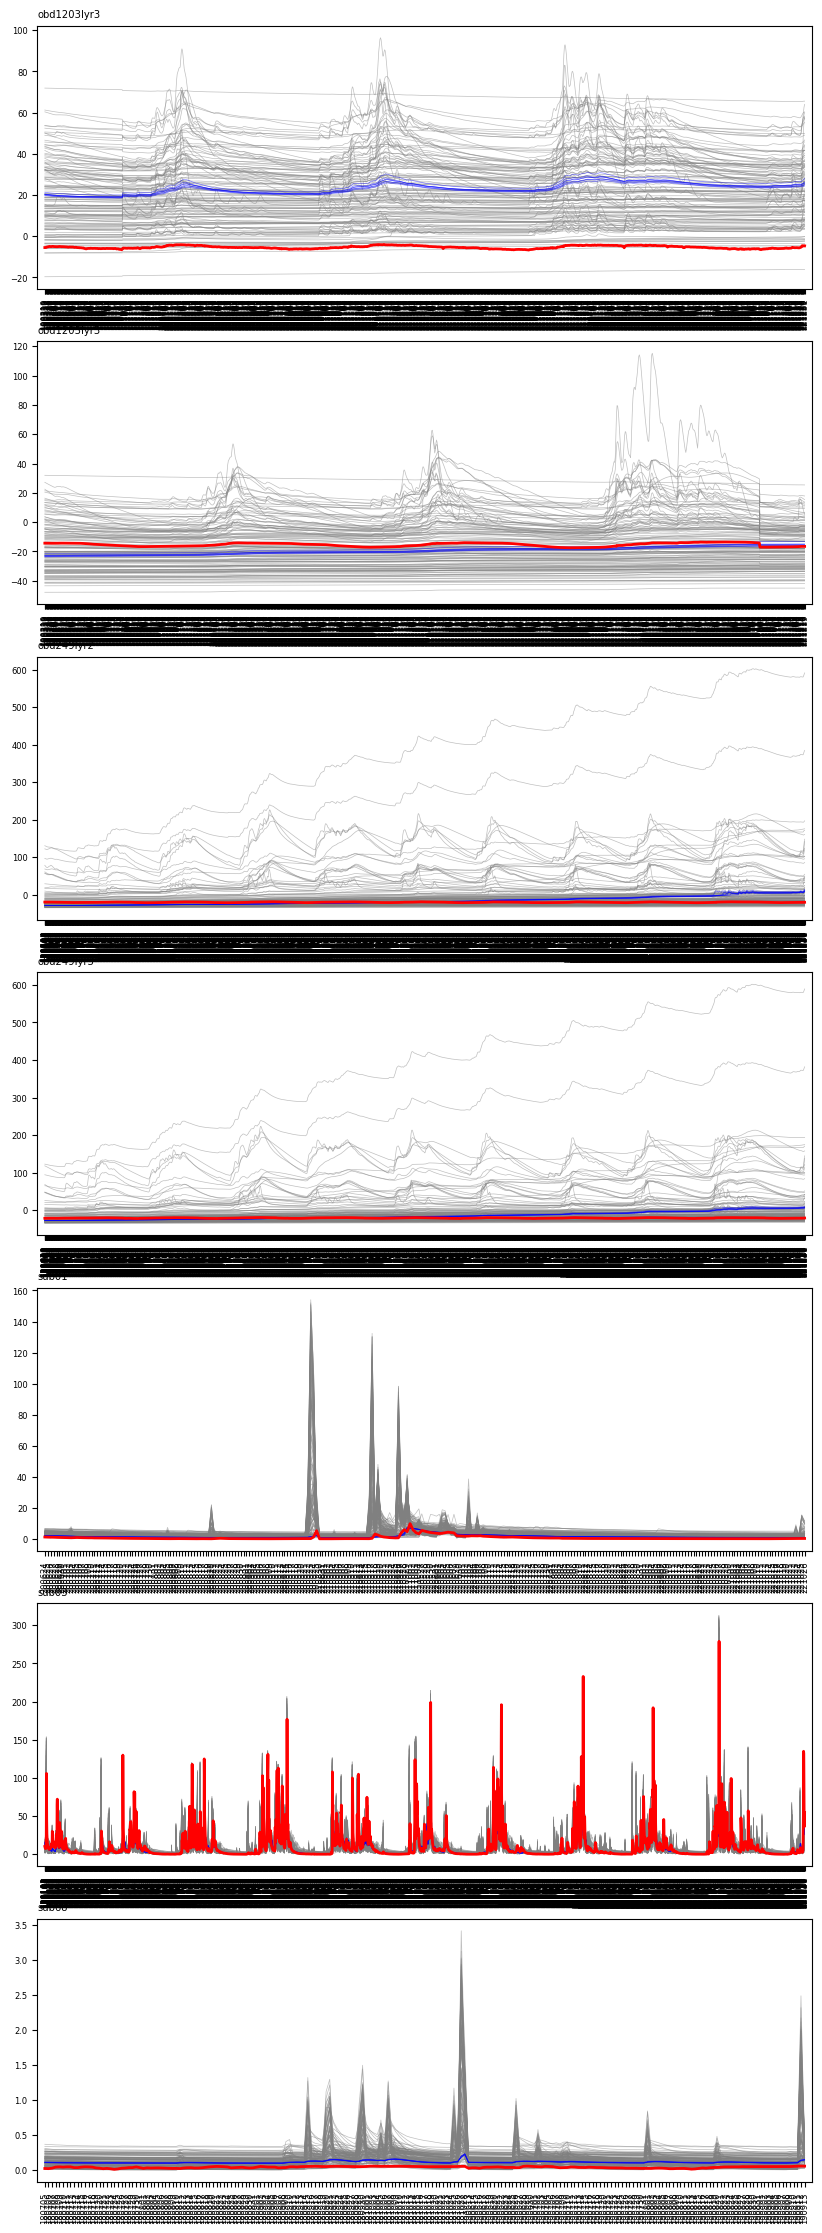

In [13]:
analyzer.plot_tseries_ensembles(pst, pr_oe, pt_oe, dot=False)

<Figure size 800x1050 with 0 Axes>

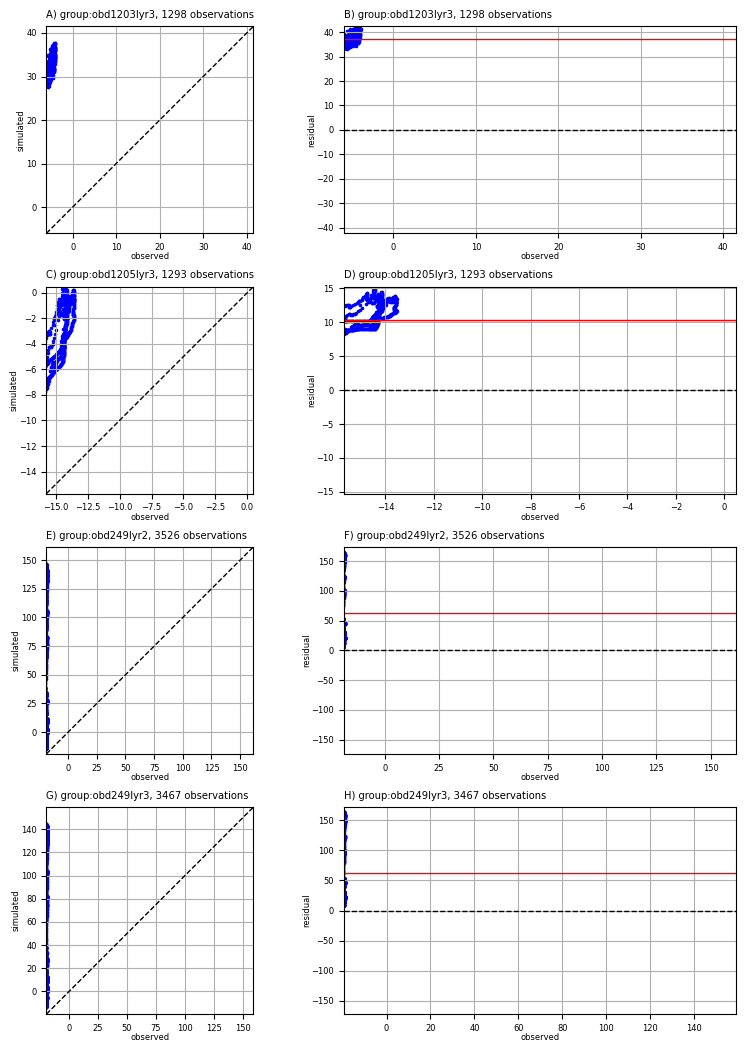

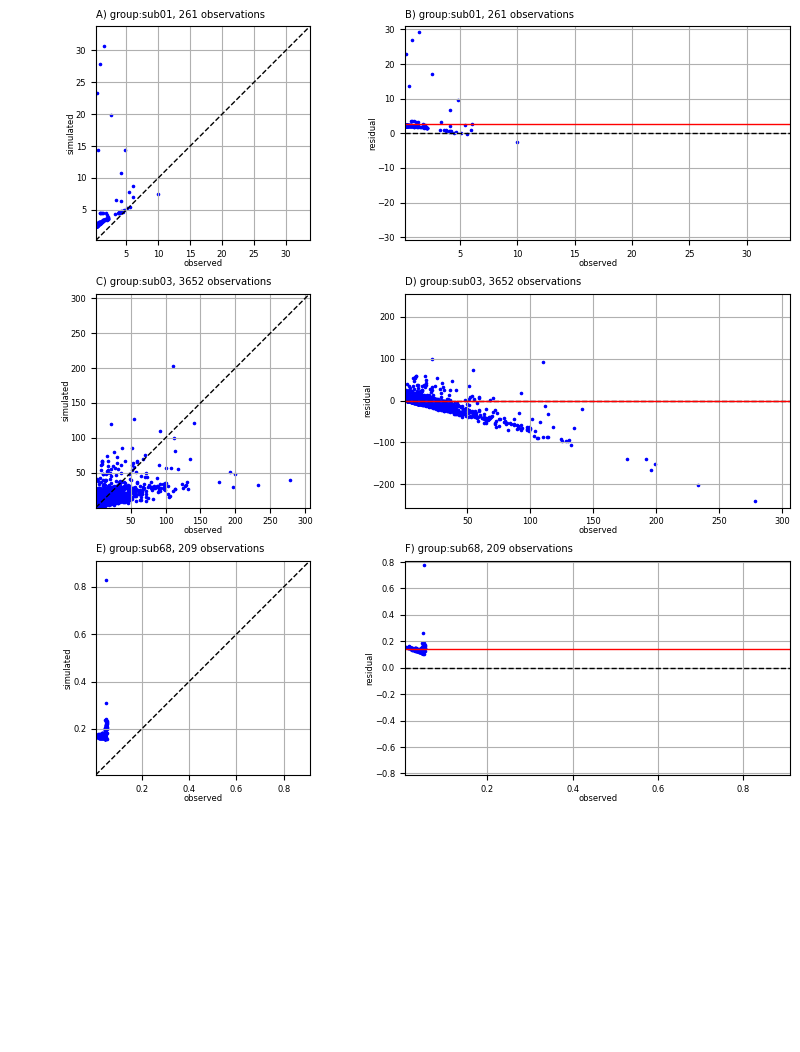

In [14]:
# plot 1 to 1 scatter plot and residuals
pyemu.plot_utils.res_1to1(pst);

In [15]:
# check phi values
pt_oe.phi_vector

real_name
21     190931.222632
32     186442.271236
153    184299.386827
203    186174.036688
218    185772.237677
236    186284.287832
277    185437.588154
dtype: float64

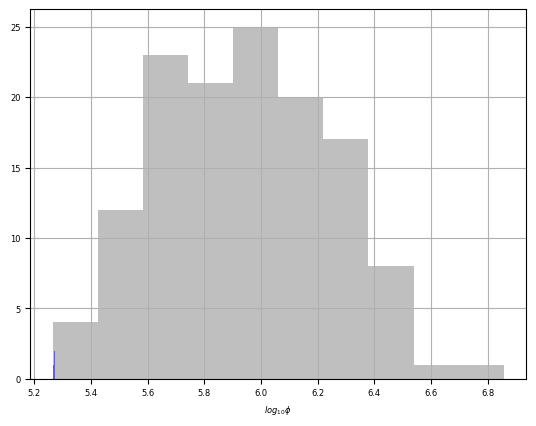

In [12]:
# plot progress
fig,ax = plt.subplots(1,1)
pr_oe.phi_vector.apply(np.log10).hist(ax=ax,fc="0.5",ec="none",alpha=0.5,density=False)
pt_oe.phi_vector.apply(np.log10).hist(ax=ax,fc="b",ec="none",alpha=0.5,density=False)
_ = ax.set_xlabel("$log_{10}\\phi$")

## 05.2 Prior and Posterior parameter probability

In [8]:
prior_df = pyemu.ParameterEnsemble.from_csv(
    pst=pst,filename=f'{pst_file[:-4]}.0.par.csv'
    )
post_df = pyemu.ParameterEnsemble.from_csv(
    pst=pst,filename=f'{pst_file[:-4]}.{post_iter_num}.par.csv')

In [13]:
df_pars = pd.read_csv(f'{pst_file[:-4]}.par_data.csv')
sel_pars = df_pars.loc[df_pars["partrans"]=='log']

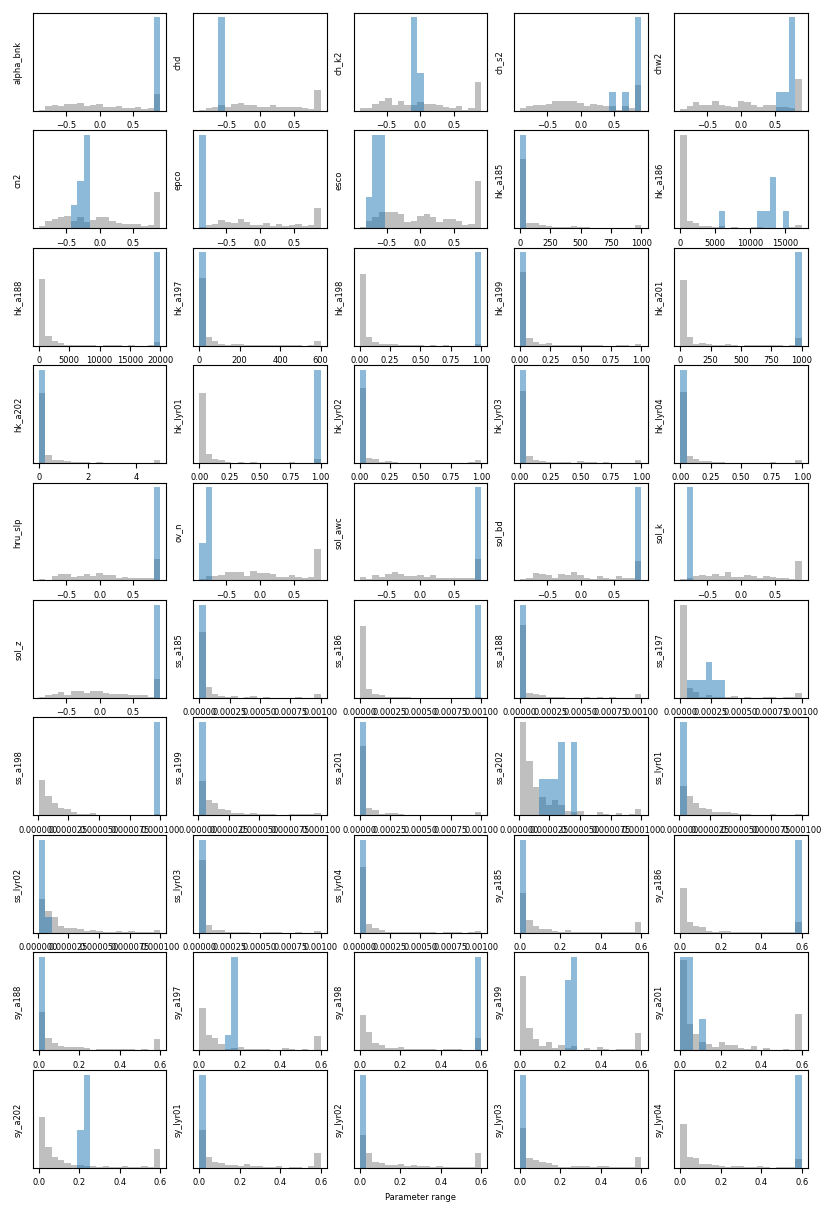

In [14]:
analyzer.plot_prior_posterior_par_hist(pst, prior_df, post_df, sel_pars, width=10,height=15, ncols=5)

## 05.3 Predictive Uncertainty

In [ ]:
swatmf_viz.plot_tseries_ensembles(pst, pr_oe, pt_oe, height=6, dot=True)

In [ ]:
os.getcwd()

In [ ]:
pst.parrep(parfile=os.path.join(m_d, "mb_zon_rw_ies.{0}.base.csv".format(pst.control_data.noptmax)))

In [ ]:
# updates the model input files with parameter values
pst.write_input_files(pst_path=m_d)

In [ ]:
# run the model forward run; this applies all the SWAT and MODFLOW paarameters, executes SWAT-MODFLOW 
os.chdir(m_d)
pyemu.os_utils.run('python forward_run.py')